[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py_ua/syn_ua_07_active_media_waves.ipynb)


# 07. Хімія БЖ, збудливі середовища і хвилі

_Магістерський курс «Вступ до синергетики» · українська версія_

> **Провідне питання:** Як хімічний зворотний зв'язок породжує локальні коливання, а після додавання дифузії — хвилі збудження?

**Як працювати з ноутбуком.** Виконуйте комірки послідовно, згори донизу. Якщо не зазначено інше, усі параметри безрозмірні. Пояснюйте зміст кожної діагностики: сама лише ефектна траєкторія ще не доводить самоорганізації.


## Результати навчання

Після опрацювання модуля ви зможете:

- пов'язати хімію реакції Бєлоусова—Жаботинського зі змінними орегонатора та контурами зворотного зв'язку;
- чисельно інтегрувати жорстку модель орегонатора й відрізняти модельні концентрації від безпосередньо спостережуваних величин;
- розрізняти бістабільну, збудливу та коливальну локальну кінетику;
- пояснювати розділення часових масштабів активатора та інгібітора;
- вимірювати швидкість імпульсу і рефрактерні ефекти в просторовій моделі.


## Необхідний вступ: нуль-ізокліни, цикли і збудливість

Для двовимірної системи $\dot u=f(u,v)$, $\dot v=g(u,v)$ криві $f=0$ і $g=0$ називають нуль-ізоклінами; їх перетини є стаціонарними точками. Стійкий граничний цикл підтримує коливання без повторних зовнішніх поштовхів. Збудлива система, навпаки, має стійкий стан спокою, але збурення понад поріг запускає велику екскурсію у фазовому просторі, після якої система відновлюється.

Нуль-ізокліни швидкого активатора та повільного інгібітора дають наочне геометричне пояснення обох режимів. У просторі дифузія дозволяє збудженій ділянці перевести сусідню через поріг. Повільна змінна відновлення залишає позаду рефрактерний «хвіст», який визначає напрям поширення і мінімальну відстань між хвилями.


## Реакція Бєлоусова—Жаботинського: спочатку хімія, потім рівняння

Реакція БЖ — це родина кислотних окиснень органічного субстрату броматом; часто використовують малонову кислоту та окисно-відновний каталізатор, наприклад церій або фероїн. Поки зберігається запас реагентів, це відкрита за енергетичним балансом дисипативна хімічна система. У перемішуваному закритому реакторі коливання зрештою згасають через виснаження реагентів; у проточному реакторі підживлення може підтримувати нерівноважний стан.

Механізм Філда—Кереша—Нойєса впорядковує хімію у взаємопов'язані контури зворотного зв'язку. Бромиста кислота $X=[\mathrm{HBrO_2}]$ бере участь в автокаталітичному броматному шляху і є швидким активатором. Бромід $Y=[\mathrm{Br^-}]$ пригнічує цей шлях і діє як інгібітор. Окиснена форма каталізатора $Z$ — наприклад, $[\mathrm{Ce^{IV}}]$ — забезпечує повільніший негативний зворотний зв'язок через взаємодію з органічним субстратом. Чергування бромідного пригнічення й автокаталітичного окиснення породжує коливання концентрацій та кольору каталізатора.

Стандартна безрозмірна тризмінна редукція — орегонатор:

$$\varepsilon_x\dot x=qy-xy+x(1-x),$$
$$\varepsilon_y\dot y=-qy-xy+fz,$$
$$\dot z=x-z.$$

Змінні є масштабованими концентраціями, а не каналами кольорового зображення. Малі $\varepsilon$ кодують розділення хімічних часових масштабів. Орегонатор відтворює архітектуру зворотних зв'язків і якісні коливання, але не є кількісно повним механізмом для кожного рецепта реакції БЖ.


## Візуалізація: хвильові структури реакції Бєлоусова—Жаботинського

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d9/The_Belousov-Zhabotinsky_Reaction.gif" width="420" alt="Комп'ютерна симуляція хвильових структур реакції Бєлоусова—Жаботинського">
</div>

Анімація показує, як локальні хімічні коливання та просторове перенесення породжують фронти, спіральні хвилі й складну еволюцію макроскопічної структури. Це **комп'ютерна симуляція**, а не відеозапис реакції в чашці. Тому її слід читати як візуалізацію поля стану; відповідність конкретним концентраціям залежить від використаної моделі та кольорового кодування.

*Джерело:* [Wikimedia Commons — *The Belousov-Zhabotinsky Reaction.gif*](https://commons.wikimedia.org/wiki/File:The_Belousov-Zhabotinsky_Reaction.gif), автор Simpsons contributor, суспільне надбання.


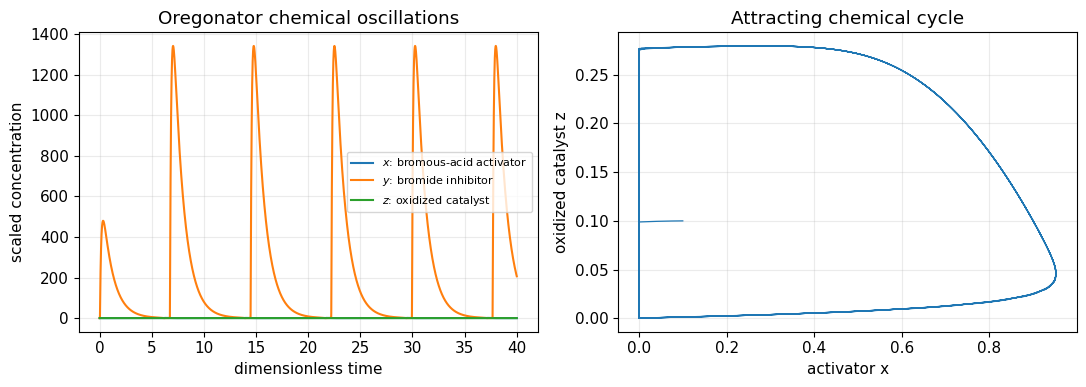

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

from scipy.integrate import solve_ivp

eps_x, eps_y, q, f = 9.9e-3, 1.98e-5, 7.62e-5, 1.0

def oregonator(t, state):
    x, y, z = state
    return ((q*y - x*y + x*(1-x))/eps_x,
            (-q*y - x*y + f*z)/eps_y,
            x-z)

# The chemistry is stiff: Radau is used rather than a large explicit step.
t_bz = np.linspace(0, 40, 5000)
bz = solve_ivp(oregonator, (0, 40), [0.1, 0.1, 0.1], t_eval=t_bz,
               method="Radau", rtol=2e-7, atol=1e-10)
if not bz.success:
    raise RuntimeError(bz.message)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(bz.t, bz.y[0], label=r"$x$: bromous-acid activator")
ax[0].plot(bz.t, bz.y[1], label=r"$y$: bromide inhibitor")
ax[0].plot(bz.t, bz.y[2], label=r"$z$: oxidized catalyst")
ax[0].set(xlabel="dimensionless time", ylabel="scaled concentration",
          title="Oregonator chemical oscillations")
ax[0].legend(fontsize=8)
ax[1].plot(bz.y[0], bz.y[2], lw=0.9)
ax[1].set(xlabel="activator x", ylabel="oxidized catalyst z",
          title="Attracting chemical cycle")
plt.tight_layout()


## Від добре перемішаного осцилятора до хімічних хвиль

У добре перемішаній посудині стан майже однорідний у просторі, а траєкторія орегонатора описує часові коливання. У неперемішуваному тонкому шарі молекулярна дифузія зв'язує сусідні елементи об'єму. Локальне збудження може залучити сусідню ділянку, а повільне відновлення залишає рефрактерну зону. Мішенеподібні структури та спіралі — це просторово-часові поля концентрацій, а не матеріальні об'єкти, що рухаються чашкою.

Рівняння ФіцГ'ю—Нагумо нижче зберігають цю геометрію «активатор—відновлення» у навмисно узагальненій формі. Вони зручні для вивчення хвиль, але не є детальною стехіометричною моделлю реакції БЖ.


## Динаміка «активатор—інгібітор»

Безрозмірне поле ФіцГ'ю—Нагумо описується рівняннями

$$\partial_tu=D_u\partial_x^2u+u-\frac{u^3}{3}-v+I,\qquad
\partial_tv=\varepsilon(u+a-bv).$$

Швидкий активатор $u$ формує передній фронт, а повільна змінна відновлення $v$ підвищує ефективний поріг позаду нього і створює рефрактерність. Рухомі імпульси є гомоклінічними структурами в супутній координаті $\xi=x-ct$.


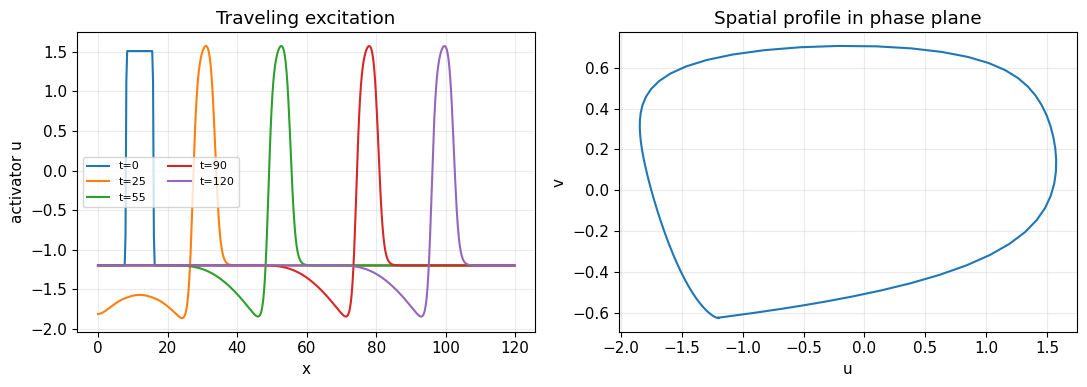

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

N, L, dt, steps = 500, 120.0, 0.01, 12000
dx = L/N
x = np.linspace(0, L, N, endpoint=False)
Du, eps, a, b, I = 0.8, 0.08, 0.7, 0.8, 0.0
u = -1.2*np.ones(N)
v = -0.62*np.ones(N)
u[(x > 8) & (x < 16)] = 1.5

def lap_neumann(z):
    padded = np.pad(z, 1, mode="edge")
    return (padded[:-2] - 2*padded[1:-1] + padded[2:]) / dx**2

snapshots = []
for n in range(steps):
    u += dt*(Du*lap_neumann(u) + u - u**3/3 - v + I)
    v += dt*eps*(u + a - b*v)
    if n in [0, 2500, 5500, 9000, steps-1]:
        snapshots.append((n*dt, u.copy(), v.copy()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for t, us, vs in snapshots:
    ax[0].plot(x, us, label=f"t={t:.0f}")
ax[0].set(xlabel="x", ylabel="activator u", title="Traveling excitation")
ax[0].legend(ncol=2, fontsize=8)
ax[1].plot(snapshots[-1][1], snapshots[-1][2])
ax[1].set(xlabel="u", ylabel="v", title="Spatial profile in phase plane")
plt.tight_layout()


## Оцінюване завдання

Частина A: оцініть період коливань орегонатора за послідовними максимумами $z$, потім змінюйте $f$ і визначте, де стійкі коливання зникають; переконайтеся, що висновок нечутливий до допусків інтегратора. Частина B: розробіть автоматичний оцінювач положення імпульсу ФіцГ'ю—Нагумо, виміряйте залежність швидкості від $D_u$ та оцініть рефрактерний час за допомогою двох стимулів. Чітко відокремте висновки про хімію БЖ від висновків, що стосуються лише узагальненої моделі збудливого середовища.

Подання має містити чітке твердження, його математичне або фізичне обґрунтування, числові свідчення та принаймні одне обмеження висновку.


## Література та атрибуція

**Основне читання з локальної бібліотеки:** Mikhailov, *Foundations of Synergetics I: Distributed Active Systems*, розділи про коливальні та збудливі середовища; Kuramoto, *Chemical Oscillations, Waves, and Turbulence*.

**Перевірені вебджерела:**
- [Scholarpedia: реакція Бєлоусова—Жаботинського](https://www.scholarpedia.org/article/Belousov-Zhabotinsky_reaction)
- [Scholarpedia: Oregonator](https://www.scholarpedia.org/article/Oregonator)
- [Mikhailov, Foundations of Synergetics I](https://doi.org/10.1007/978-3-642-78556-6)
- [Scholarpedia: reaction-diffusion systems](https://www.scholarpedia.org/article/Reaction-diffusion_systems)

Локальні книги є наданими матеріалами курсу. Вебпосилання мають додатковий характер; їх перевірено 04.09.2026.
